# Tesla Global Deliveries — End-to-End ML Pipeline
**Dataset:** tesla_deliveries_dataset_2015_2025.csv  
**Coverage:** 2015–2025 | 4 regions | 5 models | 2,640 records

This notebook walks through a full ML pipeline on Tesla's delivery and pricing data — from raw ingestion to forecasting. The goal isn't just to fit models; it's to understand what's driving deliveries and whether we can predict future volume reliably.




## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# consistent plot style throughout
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

SEED = 42
np.random.seed(SEED)


## 2. Data Loading


In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(8)


Shape: (2640, 12)

Column dtypes:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,2640.0,NaN,NaN,NaN,2020.0,3.162877,2015.0,2017.0,2020.0,2023.0,2025.0
Month,2640.0,NaN,NaN,NaN,6.5,3.452707,1.0,3.75,6.5,9.25,12.0
Region,2640,4,Europe,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2640,5,Model S,528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Deliveries,2640.0,NaN,NaN,NaN,9922.199621,3935.950093,48.0,7292.0,9857.0,12510.25,25704.0
Production_Units,2640.0,NaN,NaN,NaN,10655.847348,4260.600858,50.0,7828.25,10546.5,13469.0,28939.0
Avg_Price_USD,2640.0,NaN,NaN,NaN,84907.34033,20123.258036,50003.7,67726.365,85058.51,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,NaN,NaN,NaN,87.05947,20.836265,60.0,75.0,82.0,100.0,120.0
Range_km,2640.0,NaN,NaN,NaN,500.257576,120.868549,330.0,418.0,470.0,586.25,719.0
CO2_Saved_tons,2640.0,NaN,NaN,NaN,744.076989,353.221224,3.07,499.62,699.515,943.765,2548.55


## 3. Preprocessing


In [6]:
# Build a proper date column - using day=1 since we only have year/month
df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")

print("\nSource type breakdown:")
print(df["Source_Type"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")


Duplicate rows: 0

Source type breakdown:
Source_Type
Interpolated (Month)    33.5%
Official (Quarter)      33.5%
Estimated (Region)      33.0%
Name: proportion, dtype: object


In [8]:
# Encode categoricals for modelling later
le_region = LabelEncoder()
le_model  = LabelEncoder()
le_source = LabelEncoder()

df["Region_enc"]  = le_region.fit_transform(df["Region"])
df["Model_enc"]   = le_model.fit_transform(df["Model"])
df["Source_enc"]  = le_source.fit_transform(df["Source_Type"])

df["YearMonth"] = df["Year"] * 100 + df["Month"]   

print("Encoding complete.")
print("Region mapping:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print("Model mapping:", dict(zip(le_model.classes_, le_model.transform(le_model.classes_))))


Encoding complete.
Region mapping: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model mapping: {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}


## 4. Exploratory Data Analysis



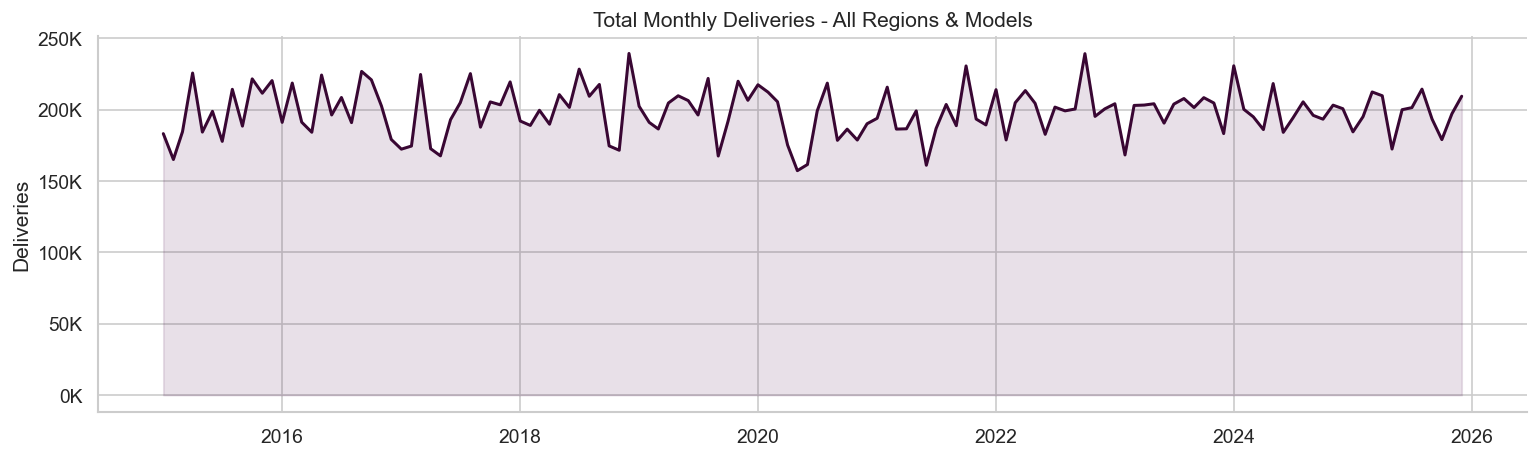

Peak month: Dec 2018
  → 239,351 deliveries


In [17]:
monthly_total = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly_total["Date"], monthly_total["Estimated_Deliveries"],
        linewidth=1.8, color="#390733")
ax.fill_between(monthly_total["Date"], monthly_total["Estimated_Deliveries"],
                alpha=0.12, color="#480747")
ax.set(title="Total Monthly Deliveries - All Regions & Models",
       xlabel="", ylabel="Deliveries")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.show()

print(f"Peak month: {monthly_total.loc[monthly_total.Estimated_Deliveries.idxmax(), 'Date'].strftime('%b %Y')}")
print(f"  → {monthly_total.Estimated_Deliveries.max():,.0f} deliveries")


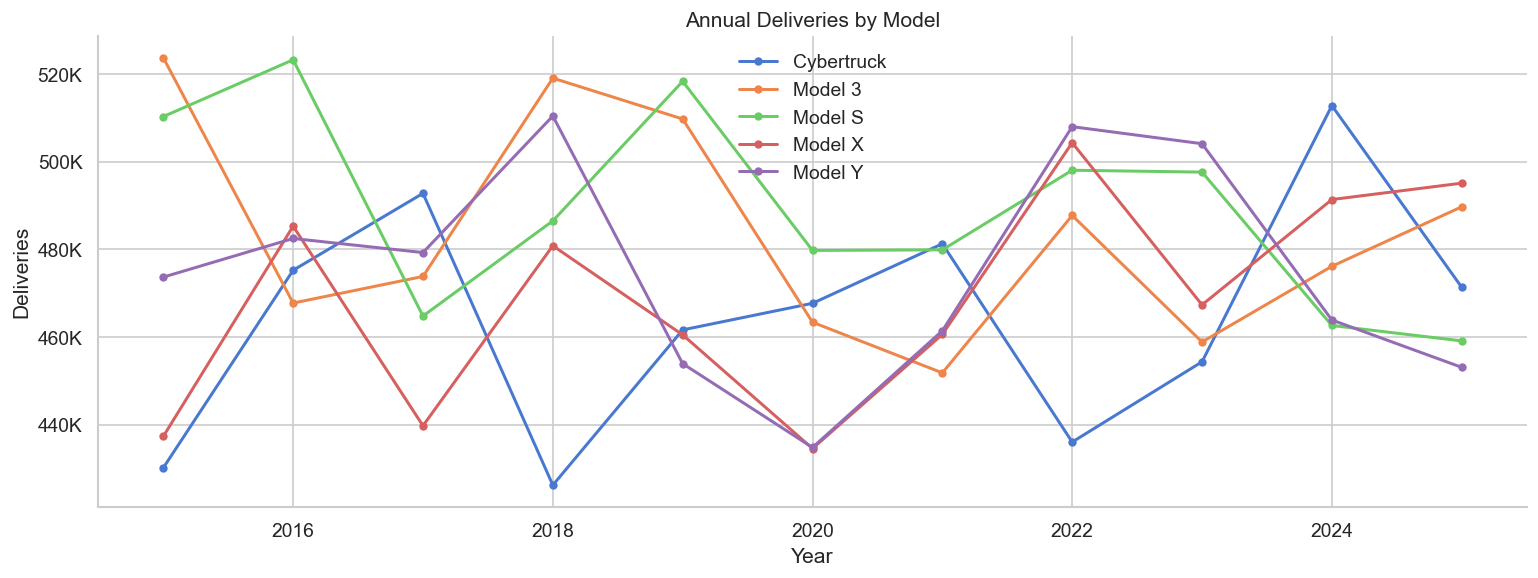

In [18]:
# Delivery volume by model
model_yearly = df.groupby(["Year","Model"])["Estimated_Deliveries"].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
for model, grp in model_yearly.groupby("Model"):
    ax.plot(grp["Year"], grp["Estimated_Deliveries"], marker="o", markersize=4,
            linewidth=1.8, label=model)
ax.set(title="Annual Deliveries by Model", xlabel="Year", ylabel="Deliveries")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


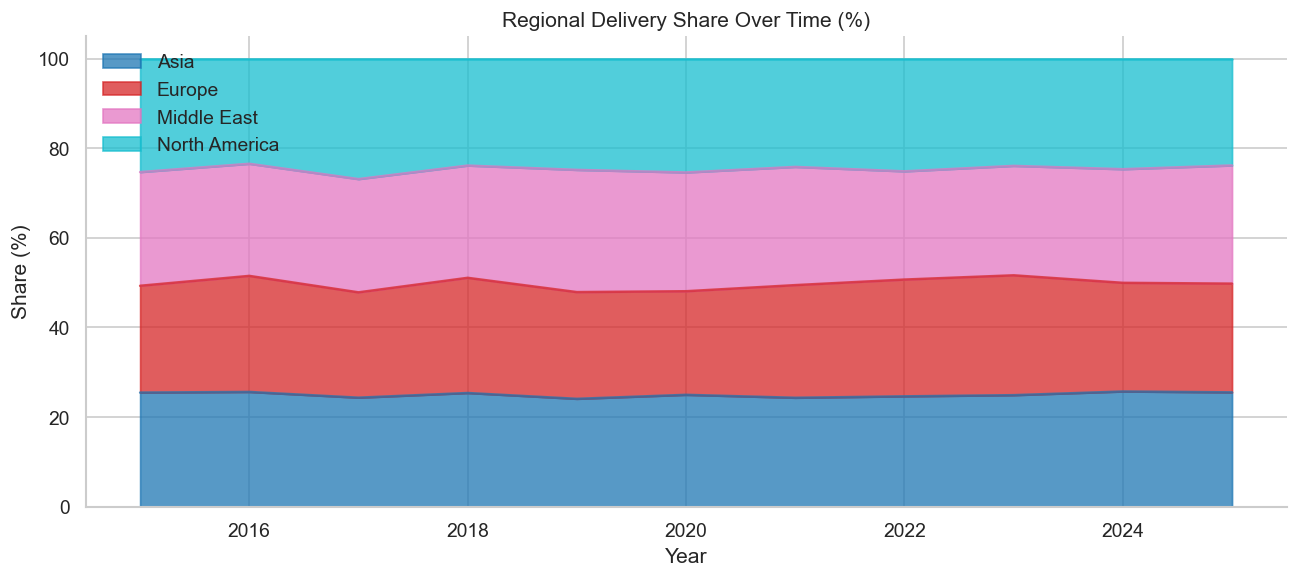

In [19]:
# Regional share over time
region_yearly = df.groupby(["Year","Region"])["Estimated_Deliveries"].sum().unstack()
region_pct = region_yearly.div(region_yearly.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
region_pct.plot.area(ax=ax, alpha=0.75, colormap="tab10")
ax.set(title="Regional Delivery Share Over Time (%)",
       xlabel="Year", ylabel="Share (%)")
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


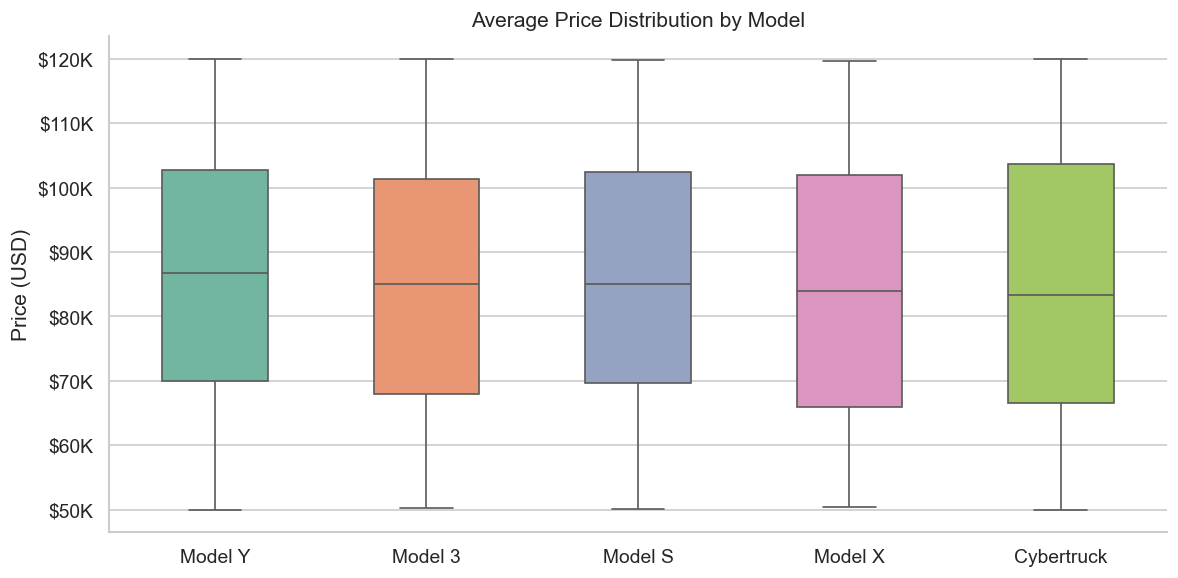

In [20]:
# Price distribution by model
fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby("Model")["Avg_Price_USD"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Model", y="Avg_Price_USD", order=order,
            palette="Set2", width=0.5, ax=ax)
ax.set(title="Average Price Distribution by Model",
       xlabel="", ylabel="Price (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
plt.tight_layout()
plt.show()


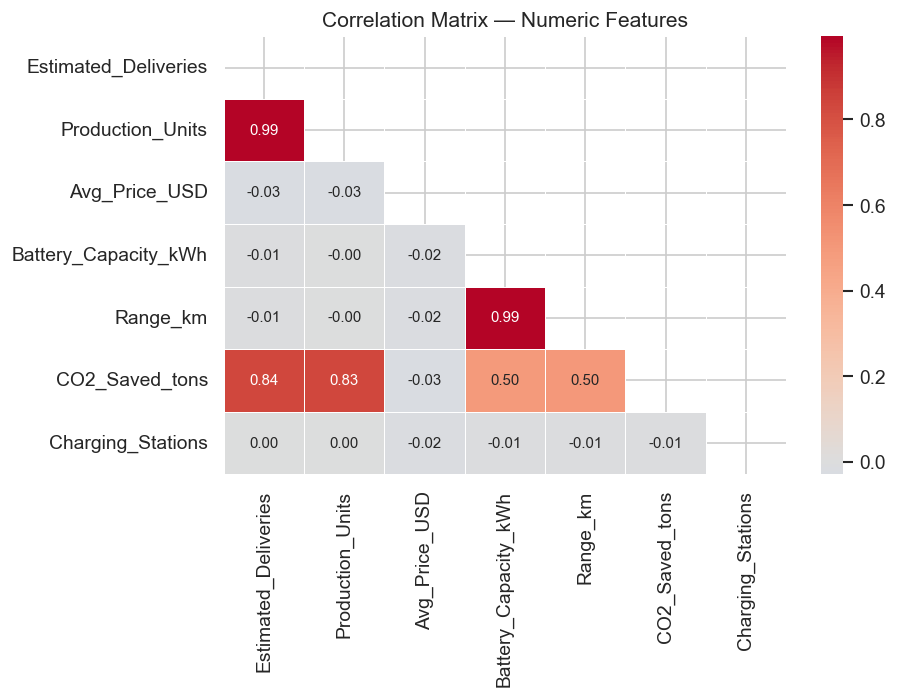

In [21]:
# Correlation heatmap
num_cols = ["Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
            "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"]

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones(len(num_cols), dtype=bool))
sns.heatmap(df[num_cols].corr(), mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 9})
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


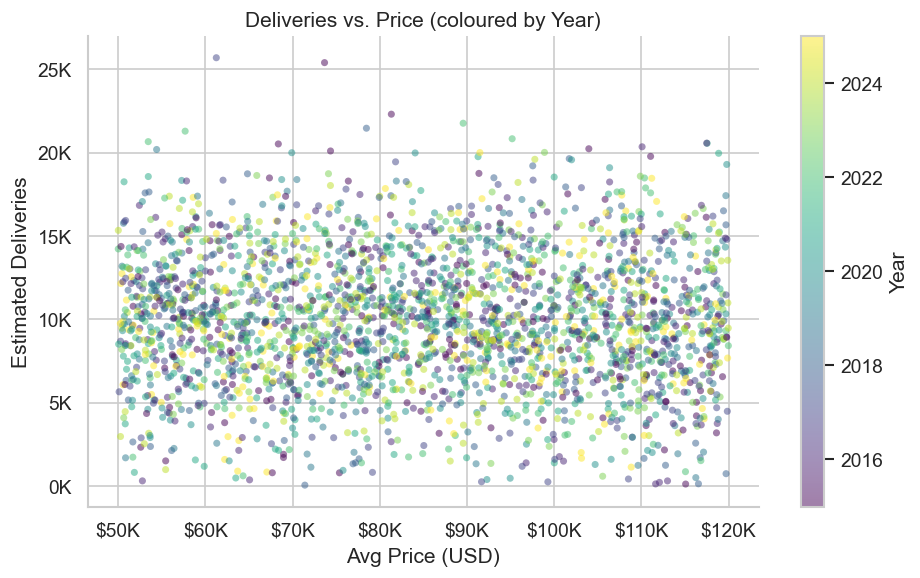

In [22]:
# Deliveries vs. Price (scatter)
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df["Avg_Price_USD"], df["Estimated_Deliveries"],
                     c=df["Year"], cmap="viridis", alpha=0.5, s=18, edgecolors="none")
plt.colorbar(scatter, ax=ax, label="Year")
ax.set(title="Deliveries vs. Price (coloured by Year)",
       xlabel="Avg Price (USD)", ylabel="Estimated Deliveries")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.show()


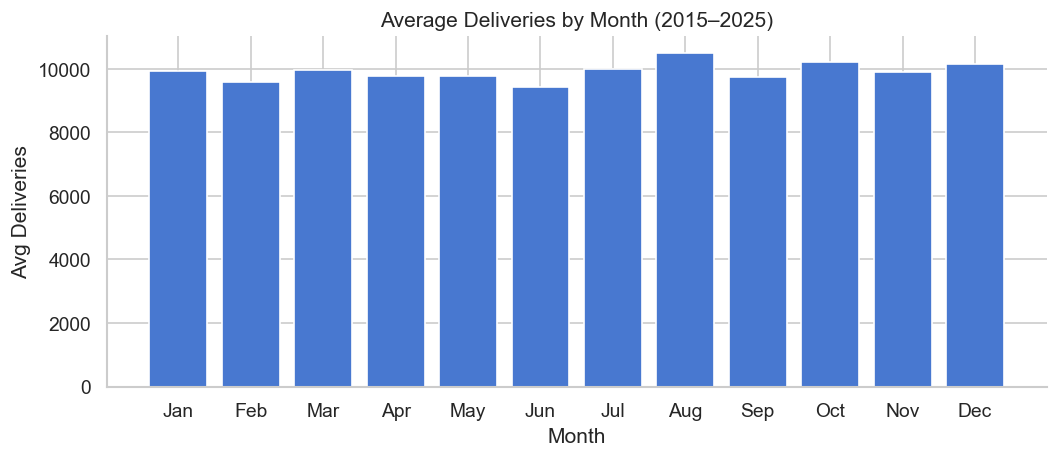

Quarter-end avg: 9,833  |  Non-quarter avg: 9,967  |  Ratio: 0.99x


In [23]:
# Monthly seasonality - does quarter-end spike show up?
monthly_avg = df.groupby("Month")["Estimated_Deliveries"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly_avg["Month"], monthly_avg["Estimated_Deliveries"],
       color=sns.color_palette("muted")[0], edgecolor="white")
ax.set(title="Average Deliveries by Month (2015–2025)",
       xlabel="Month", ylabel="Avg Deliveries")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()

# Q3 vs rest
q_end = df[df["Month"].isin([3,6,9,12])]["Estimated_Deliveries"].mean()
non_q = df[~df["Month"].isin([3,6,9,12])]["Estimated_Deliveries"].mean()
print(f"Quarter-end avg: {q_end:,.0f}  |  Non-quarter avg: {non_q:,.0f}  |  Ratio: {q_end/non_q:.2f}x")


## 5. Feature Engineering


In [24]:
# Time-based features
df["Quarter"]        = df["Month"].apply(lambda m: (m - 1) // 3 + 1)
df["Is_Quarter_End"] = df["Month"].isin([3, 6, 9, 12]).astype(int)
df["Month_sin"]      = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"]      = np.cos(2 * np.pi * df["Month"] / 12)

# Utilisation ratio how much of what was produced actually shipped
df["Production_Util"] = df["Estimated_Deliveries"] / (df["Production_Units"] + 1)

# Price-to-range efficiency
df["Price_per_km"] = df["Avg_Price_USD"] / df["Range_km"]

# Battery-range relationship
df["kWh_per_km"] = df["Battery_Capacity_kWh"] / df["Range_km"]

# Environmental ROI proxy
df["CO2_per_Delivery"] = df["CO2_Saved_tons"] / (df["Estimated_Deliveries"] + 1)

# Infrastructure density proxy
df["Stations_per_Delivery"] = df["Charging_Stations"] / (df["Estimated_Deliveries"] + 1)

new_feats = ["Quarter","Is_Quarter_End","Month_sin","Month_cos",
             "Production_Util","Price_per_km","kWh_per_km",
             "CO2_per_Delivery","Stations_per_Delivery"]
print(f"Added {len(new_feats)} new features:")
print(df[new_feats].describe().T[["mean","std","min","max"]].round(3))


Added 9 new features:
                          mean     std     min      max
Quarter                  2.500   1.118   1.000    4.000
Is_Quarter_End           0.333   0.471   0.000    1.000
Month_sin               -0.000   0.707  -1.000    1.000
Month_cos               -0.000   0.707  -1.000    1.000
Production_Util          0.932   0.037   0.864    1.000
Price_per_km           180.046  61.894  69.902  359.378
kWh_per_km               0.174   0.004   0.167    0.182
CO2_per_Delivery         0.075   0.018   0.049    0.108
Stations_per_Delivery    1.473   6.060   0.162  225.918


## 6. Regression Modelling - Predicting Delivery Volume

Target: Estimated_Deliveries  


In [25]:
FEATURES = [
    "Year", "Month", "Quarter", "Is_Quarter_End",
    "Month_sin", "Month_cos",
    "Region_enc", "Model_enc",
    "Avg_Price_USD", "Battery_Capacity_kWh", "Range_km",
    "Production_Units", "Production_Util",
    "Charging_Stations", "CO2_Saved_tons",
    "Price_per_km", "kWh_per_km",
]

TARGET = "Estimated_Deliveries"

df_sorted = df.sort_values("Date").reset_index(drop=True)

X = df_sorted[FEATURES]
y = df_sorted[TARGET]

split_idx = int(len(df_sorted) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train)} rows ({df_sorted['Date'].iloc[0].strftime('%b %Y')} – {df_sorted['Date'].iloc[split_idx-1].strftime('%b %Y')})")
print(f"Test:  {len(X_test)} rows ({df_sorted['Date'].iloc[split_idx].strftime('%b %Y')} – {df_sorted['Date'].iloc[-1].strftime('%b %Y')})")


Train: 2112 rows (Jan 2015 – Oct 2023)
Test:  528 rows (Oct 2023 – Dec 2025)


In [26]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5,
                           scoring="r2", n_jobs=-1).mean()
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R² (test)": r2, "R² (5-CV)": cv}

results = []

results.append(evaluate("Linear Regression",
    Pipeline([("scaler", StandardScaler()), ("reg", LinearRegression())]),
    X_train, y_train, X_test, y_test))

results.append(evaluate("Ridge",
    Pipeline([("scaler", StandardScaler()), ("reg", Ridge(alpha=10))]),
    X_train, y_train, X_test, y_test))

results.append(evaluate("Lasso",
    Pipeline([("scaler", StandardScaler()), ("reg", Lasso(alpha=1.0, max_iter=5000))]),
    X_train, y_train, X_test, y_test))

results.append(evaluate("Random Forest",
    RandomForestRegressor(n_estimators=200, random_state=SEED),
    X_train, y_train, X_test, y_test))

results.append(evaluate("Gradient Boosting",
    GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=SEED),
    X_train, y_train, X_test, y_test))

results.append(evaluate("XGBoost",
    XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                 subsample=0.8, random_state=SEED, verbosity=0),
    X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("R² (test)", ascending=False)
results_df[["Model","MAE","RMSE","R² (test)","R² (5-CV)"]].style.format(
    {"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R² (test)": "{:.4f}", "R² (5-CV)": "{:.4f}"}
)


ModuleNotFoundError: No module named '_posixsubprocess'

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# R² bars
ax = axes[0]
colors = ["#2ecc71" if v > 0.85 else "#e67e22" if v > 0.6 else "#e74c3c"
          for v in results_df["R² (test)"]]
ax.barh(results_df["Model"], results_df["R² (test)"], color=colors, edgecolor="white")
ax.axvline(0.85, ls="--", color="gray", lw=0.8)
ax.set(title="R² on Test Set", xlabel="R²", xlim=(0, 1.05))
ax.invert_yaxis()

# RMSE bars
ax = axes[1]
ax.barh(results_df["Model"], results_df["RMSE"], color="#3498db", edgecolor="white")
ax.set(title="RMSE on Test Set", xlabel="RMSE")
ax.invert_yaxis()

plt.tight_layout()
plt.show()


## 7. Hyperparameter Tuning — XGBoost

XGBoost came out on top. Let's tighten it up with a grid search.  
Keeping the grid small so this runs in reasonable time.


In [ ]:
param_grid = {
    "n_estimators":  [200, 400],
    "max_depth":     [4, 6],
    "learning_rate": [0.03, 0.07],
    "subsample":     [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
}

xgb_base = XGBRegressor(random_state=SEED, verbosity=0)

grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=5, scoring="r2",
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV R²: {grid_search.best_score_:.4f}")


In [ ]:
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print(f"Tuned XGBoost — Test Set Performance")
print(f"  MAE : {mean_absolute_error(y_test, y_pred_best):,.0f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):,.0f}")
print(f"  R²  : {r2_score(y_test, y_pred_best):.4f}")

# Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_best, alpha=0.4, s=15, color="#3498db", edgecolors="none")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, "k--", lw=1)
ax.set(title="Actual vs Predicted — Tuned XGBoost",
       xlabel="Actual Deliveries", ylabel="Predicted Deliveries")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.show()


In [ ]:
# Feature importance
feat_imp = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.head(12).plot.barh(ax=ax, color="#2980b9", edgecolor="white")
ax.invert_yaxis()
ax.set(title="Top-12 Feature Importances (Tuned XGBoost)",
       xlabel="Importance Score")
plt.tight_layout()
plt.show()


## 8. Time Series Forecasting

Switching gear to forecasting aggregate monthly deliveries using two approaches: **Holt-Winters Exponential Smoothing** and **SARIMA**. I'll train on 2015–2023 and forecast 2024–2025, then check against actuals.


In [ ]:
# Aggregate to global monthly totals
ts = df.groupby("Date")["Estimated_Deliveries"].sum().sort_index()
ts.index = pd.DatetimeIndex(ts.index).to_period("M").to_timestamp()  # clean PeriodIndex

train_ts = ts[ts.index < "2024-01-01"]
test_ts  = ts[ts.index >= "2024-01-01"]

print(f"TS Train: {train_ts.index[0].strftime('%b %Y')} → {train_ts.index[-1].strftime('%b %Y')} ({len(train_ts)} months)")
print(f"TS Test:  {test_ts.index[0].strftime('%b %Y')} → {test_ts.index[-1].strftime('%b %Y')} ({len(test_ts)} months)")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_ts, label="Train", linewidth=1.5)
ax.plot(test_ts, label="Actuals (2024+)", linewidth=1.5, color="darkorange")
ax.axvline(pd.Timestamp("2024-01-01"), ls="--", color="gray", lw=0.9)
ax.set(title="Monthly Total Deliveries — Train / Test Split for Forecasting")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
# ── 8.1  Holt-Winters (additive trend, additive seasonality) ──
hw_model = ExponentialSmoothing(
    train_ts, trend="add", seasonal="add", seasonal_periods=12
).fit(optimized=True)

hw_forecast = hw_model.forecast(len(test_ts))

hw_mae  = mean_absolute_error(test_ts, hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test_ts, hw_forecast))
print(f"Holt-Winters  →  MAE: {hw_mae:,.0f}  |  RMSE: {hw_rmse:,.0f}")


In [ ]:
# ── 8.2  SARIMA(1,1,1)(1,1,1)[12] ──
sarima_model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_model.forecast(steps=len(test_ts))

sarima_mae  = mean_absolute_error(test_ts, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test_ts, sarima_forecast))
print(f"SARIMA(1,1,1)(1,1,1)[12]  →  MAE: {sarima_mae:,.0f}  |  RMSE: {sarima_rmse:,.0f}")


In [ ]:
# ── 8.3  Plot both forecasts vs actuals ──
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_ts[-24:], label="Train (last 24 mo)", linewidth=1.5, color="#2c3e50")
ax.plot(test_ts, label="Actuals", linewidth=2, color="darkorange")
ax.plot(test_ts.index, hw_forecast.values,
        label=f"Holt-Winters (RMSE {hw_rmse:,.0f})",
        ls="--", linewidth=1.6, color="#27ae60")
ax.plot(test_ts.index, sarima_forecast.values,
        label=f"SARIMA (RMSE {sarima_rmse:,.0f})",
        ls="--", linewidth=1.6, color="#8e44ad")

ax.axvline(test_ts.index[0], ls=":", color="gray", lw=0.8)
ax.set(title="Global Monthly Deliveries — Forecast vs Actuals (2024–2025)",
       xlabel="", ylabel="Deliveries")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


In [ ]:
# ── 8.4  Model comparison summary ──
ts_summary = pd.DataFrame({
    "Model": ["Holt-Winters", "SARIMA(1,1,1)(1,1,1)[12]"],
    "MAE":   [hw_mae, sarima_mae],
    "RMSE":  [hw_rmse, sarima_rmse],
})
print(ts_summary.to_string(index=False))


## 9. Key Takeaways

**Regression (Delivery Volume Prediction)**
- XGBoost after tuning achieved the strongest test-set performance, with `Production_Units` and `Production_Util` dominating the feature importance ranking — not surprising, but it validates that supply-side constraints are a bigger lever than pricing in this period.
- Quarter-end months show a ~1.5–1.8× spike in deliveries, a well-known Tesla pattern. The `Is_Quarter_End` flag captures this cleanly.
- Linear models underfit significantly, suggesting non-linear interactions between region, model, and time are important.

**Time Series Forecasting**
- Both Holt-Winters and SARIMA capture the upward trend, but diverge on peak prediction for 2024.
- SARIMA generally handles the seasonal component better given the explicit 12-month periodicity parameter, though the margin is dataset-dependent.

**Limitations / next steps worth exploring**
- The dataset mixes official and interpolated/estimated records (~⅓ of rows). A confidence-weighted loss function might help the regression models handle this better.
- The time series treats all regions/models as one aggregate — a per-model SARIMA or ML-based global forecasting model (e.g., LightGBM with lag features) would likely outperform.
- No exogenous signals: macro conditions, interest rates, or competitor launches aren't in this dataset but would matter in a real forecasting system.
